In [1]:
import sqlite3
import pandas as pd
import platform

In [182]:
if platform.system() == 'Windows':
    DB_PATH = r"C:\Users\LISARR\Documents\python\01.Financeiro\inform_27.db"
elif platform.system() == 'Darwin':
    DB_PATH = "/Volumes/RR/DB/inform_27.db"
else:
    DB_PATH = "inform_27.db"

print(f"Caminho BD: {DB_PATH}")

Caminho BD: C:\Users\LISARR\Documents\python\01.Financeiro\inform_27.db


In [183]:
con = sqlite3.connect(DB_PATH)
print("Conexão estabelecida ✓")

Conexão estabelecida ✓


In [184]:
df = pd.read_sql_query("SELECT * FROM dados_2025", con)
print(f"Linhas 2025: {len(df):,}")
print(f"Colunas: {df.shape[1]}")

Linhas 2025: 190,938
Colunas: 58


In [185]:
df_2026 = pd.read_sql_query("SELECT * FROM dados_2026", con)
print(f"Linhas 2026: {len(df_2026):,}")

# Juntar
df = pd.concat([df, df_2026], ignore_index=True)
print(f"\nTotal combinado: {len(df):,}")

Linhas 2026: 97,211

Total combinado: 288,149


In [186]:
df.head()

,id,PROPIETARIO,TRAYECTO,TRANSPORTISTA,TRACTORA,REMOLQUE,INGRESODT,COSTEDT,RENTADT,PALETSDT,...,LOCDES,LUGARDESCARGA,TEMP_MERC_PED,TIPOPALETA,CAMION_TIPO,CAMION_CAPACIDAD,TIPO_COMBUSTIBLE,KMREALES,ALBARAN,ficheiro_origem
0,1,CEP,SALVESEN LOGISTICA PORTUGAL / CMTIR / cmtir porto,"TJA-TRANSPORTES J.AMARAL, S.A. -",AO-00-DT,BG813,0,0.22,-0.22,0.02,...,579957,CMTIR,RFGRFG,EUR,Trailer 33 plts,33,DIESEL,285.606,NO,SAL_DAT027 (11).xls
1,2,CEP,SALVESEN LOGISTICA PORTUGAL / CMTIR / cmtir porto,"TJA-TRANSPORTES J.AMARAL, S.A. -",AO-00-DT,BG813,0,0.11,-0.11,0.01,...,579957,CMTIR,RFGRFG,EUR,Trailer 33 plts,33,DIESEL,285.606,NO,SAL_DAT027 (11).xls
2,3,CEP,SALVESEN LOGISTICA PORTUGAL / CMTIR / cmtir porto,"TJA-TRANSPORTES J.AMARAL, S.A. -",AO-00-DT,BG813,0,0.11,-0.11,0.01,...,579957,CMTIR,RFGRFG,EUR,Trailer 33 plts,33,DIESEL,285.606,NO,SAL_DAT027 (11).xls
3,4,CEP,SALVESEN LOGISTICA PORTUGAL / CMTIR / cmtir porto,"TJA-TRANSPORTES J.AMARAL, S.A. -",AO-00-DT,BG813,0,0.67,-0.67,0.06,...,579957,CMTIR,RFGRFG,EUR,Trailer 33 plts,33,DIESEL,285.606,NO,SAL_DAT027 (11).xls
4,5,CEP,SALVESEN LOGISTICA PORTUGAL / CMTIR / cmtir porto,"TJA-TRANSPORTES J.AMARAL, S.A. -",AO-00-DT,BG813,12.33,16.45,-4.12,1.47,...,579957,CMTIR,RFGRFG,EUR,Trailer 33 plts,33,DIESEL,285.606,NO,SAL_DAT027 (11).xls


In [187]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 288149 entries, 0 to 288148
Data columns (total 58 columns):
 #   Column            Non-Null Count   Dtype
---  ------            --------------   -----
 0   id                288149 non-null  int64
 1   PROPIETARIO       288149 non-null  str  
 2   TRAYECTO          270284 non-null  str  
 3   TRANSPORTISTA     288149 non-null  str  
 4   TRACTORA          283949 non-null  str  
 5   REMOLQUE          286938 non-null  str  
 6   INGRESODT         288149 non-null  str  
 7   COSTEDT           288149 non-null  str  
 8   RENTADT           288149 non-null  str  
 9   PALETSDT          288149 non-null  str  
 10  PESO_BRUTO        288149 non-null  str  
 11  CODEUT            288149 non-null  str  
 12  ESTADO_UT         288149 non-null  str  
 13  RANGO_UT          288149 non-null  str  
 14  FCARGA            288149 non-null  str  
 15  ACTIVIDAD         288149 non-null  str  
 16  CODEDT            288149 non-null  str  
 17  ESTADO_DT         288

In [188]:
# Colunas que precisam ser numéricas
numeric_cols = ['PESO_BRUTO', 'KMREALES', 'CAMION_CAPACIDAD', 'INGRESODT', 'COSTEDT', 'RENTADT', 'PALETSDT']

for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

print("Conversões numéricas OK ✓")

Conversões numéricas OK ✓


In [189]:
df['FENTREGA_DT'] = pd.to_datetime(df['FENTREGA'], format='%Y%m%d', errors='coerce')
print(df['FENTREGA_DT'].head())

0   2025-12-31
1   2025-12-31
2   2025-12-31
3   2025-12-31
4   2025-12-31
Name: FENTREGA_DT, dtype: datetime64[us]


In [190]:
print(f"Total linhas: {len(df):,}")
print(f"\nData mín/máx: {df['FENTREGA_DT'].min()} a {df['FENTREGA_DT'].max()}")
print(f"\nCapacidades: {sorted(df['CAMION_CAPACIDAD'].dropna().unique())}")

Total linhas: 288,149

Data mín/máx: 2025-01-02 00:00:00 a 2026-07-22 00:00:00

Capacidades: [np.int64(0), np.int64(4), np.int64(5), np.int64(6), np.int64(8), np.int64(10), np.int64(12), np.int64(14), np.int64(15), np.int64(16), np.int64(18), np.int64(20), np.int64(21), np.int64(22), np.int64(24), np.int64(32), np.int64(33), np.int64(66)]


In [191]:
df_cap6 = df[df['CAMION_CAPACIDAD'] <= 6].copy()

print(f"Total linhas capacidade ≤ 6: {len(df_cap6):,}")
print(f"Capacidades presentes: {sorted(df_cap6['CAMION_CAPACIDAD'].dropna().unique())}")

Total linhas capacidade ≤ 6: 65,608
Capacidades presentes: [np.int64(0), np.int64(4), np.int64(5), np.int64(6)]


In [192]:
df['CODACT'] = pd.to_numeric(df['CODACT'], errors='coerce')

print(f"CODACT dtype: {df['CODACT'].dtype}")
print(f"CODACT valores únicos: {sorted(df['CODACT'].dropna().unique())}")
print(f"CODACT = 13 linhas: {len(df[df['CODACT'] == 13]):,}")

CODACT dtype: int64
CODACT valores únicos: [np.int64(11), np.int64(13), np.int64(28), np.int64(74), np.int64(84), np.int64(116), np.int64(118), np.int64(131), np.int64(217), np.int64(260), np.int64(262), np.int64(265), np.int64(273), np.int64(275), np.int64(278), np.int64(280), np.int64(282), np.int64(283), np.int64(287), np.int64(311), np.int64(332), np.int64(337), np.int64(353), np.int64(377), np.int64(380), np.int64(387), np.int64(391), np.int64(394), np.int64(397), np.int64(398), np.int64(399), np.int64(400), np.int64(401), np.int64(403), np.int64(404), np.int64(405), np.int64(407), np.int64(413), np.int64(415), np.int64(418), np.int64(419), np.int64(422), np.int64(429), np.int64(462), np.int64(490), np.int64(491), np.int64(492), np.int64(522), np.int64(525), np.int64(526), np.int64(539), np.int64(546), np.int64(551), np.int64(560), np.int64(588), np.int64(660), np.int64(680), np.int64(682), np.int64(711), np.int64(757), np.int64(784), np.int64(860)]
CODACT = 13 linhas: 47,909


In [193]:
df['CAMION_CAPACIDAD'] = pd.to_numeric(df['CAMION_CAPACIDAD'], errors='coerce')

print(f"CAMION_CAPACIDAD dtype: {df['CAMION_CAPACIDAD'].dtype}")
print(f"Capacidades: {sorted(df['CAMION_CAPACIDAD'].dropna().unique())}")

CAMION_CAPACIDAD dtype: int64
Capacidades: [np.int64(0), np.int64(4), np.int64(5), np.int64(6), np.int64(8), np.int64(10), np.int64(12), np.int64(14), np.int64(15), np.int64(16), np.int64(18), np.int64(20), np.int64(21), np.int64(22), np.int64(24), np.int64(32), np.int64(33), np.int64(66)]


In [194]:
df['PESO_BRUTO'] = pd.to_numeric(df['PESO_BRUTO'], errors='coerce')

print(f"PESO_BRUTO dtype: {df['PESO_BRUTO'].dtype}")
print(f"PESO_BRUTO describe:\n{df['PESO_BRUTO'].describe()}")

PESO_BRUTO dtype: float64
PESO_BRUTO describe:
count    2.881490e+05
mean     7.546340e+02
std      3.899675e+03
min      0.000000e+00
25%      1.726000e+01
50%      8.032000e+01
75%      3.146850e+02
max      1.355964e+06
Name: PESO_BRUTO, dtype: float64


In [195]:
df_6pal = df[(df['CAMION_CAPACIDAD'] <= 6) & (df['CODACT'] == 13)].copy()

print(f"Total linhas: {len(df_6pal):,}")
print(f"Capacidades: {sorted(df_6pal['CAMION_CAPACIDAD'].unique())}")
print(f"Data mín/máx: {df_6pal['FENTREGA_DT'].min()} a {df_6pal['FENTREGA_DT'].max()}")

Total linhas: 36,104
Capacidades: [np.int64(0), np.int64(4), np.int64(5), np.int64(6)]
Data mín/máx: 2025-01-03 00:00:00 a 2026-07-20 00:00:00


In [196]:
print("Prov_origem valores únicos:")
print(df_6pal['PROV_ORIGEN'].value_counts())

Prov_origem valores únicos:
PROV_ORIGEN
Lisboa     29967
Porto       3473
Coimbra     2603
Madrid        59
Faro           2
Name: count, dtype: int64


In [197]:
df_3reg = df_6pal[df_6pal['PROV_ORIGEN'].isin(['Porto', 'Coimbra', 'Lisboa'])].copy()

print(f"Total linhas após filtro: {len(df_3reg):,}")
print(f"Regiões: {df_3reg['PROV_ORIGEN'].value_counts()}")

Total linhas após filtro: 36,043
Regiões: PROV_ORIGEN
Lisboa     29967
Porto       3473
Coimbra     2603
Name: count, dtype: int64


In [198]:
rotas_por_dia_reg = df_3reg.groupby(['FENTREGA_DT', 'PROV_ORIGEN']).agg({
    'TRAYECTO': 'nunique',  # Nº rotas
    'PESO_BRUTO': 'sum'      # Peso total
}).reset_index()

rotas_por_dia_reg.columns = ['Data', 'Regiao', 'N_Rotas', 'Peso_Total']
rotas_por_dia_reg['Peso_Medio'] = (rotas_por_dia_reg['Peso_Total'] / rotas_por_dia_reg['N_Rotas']).round(2)
rotas_por_dia_reg = rotas_por_dia_reg.sort_values(['Data', 'Regiao'])

rotas_por_dia_reg = rotas_por_dia_reg[rotas_por_dia_reg['Data'].dt.year == 2026]

rotas_por_dia_reg.tail(10)

,Data,Regiao,N_Rotas,Peso_Total,Peso_Medio
748,2026-07-07,Lisboa,10,6463.82,646.38
749,2026-07-08,Lisboa,11,5127.05,466.10
750,2026-07-09,Lisboa,11,9211.59,837.42
751,2026-07-10,Lisboa,13,8672.37,667.11
752,2026-07-13,Lisboa,10,5727.92,572.79
753,2026-07-14,Lisboa,11,6432.81,584.80
754,2026-07-15,Lisboa,11,7031.20,639.20
755,2026-07-16,Lisboa,14,7182.70,513.05
756,2026-07-17,Lisboa,5,2515.72,503.14
757,2026-07-20,Lisboa,8,0.00,0.00


In [199]:
import os

ROTAS_REGIAO = {
    'Porto': {
        'cp7': ('4000-265', '4050-276', '4250-163', '4420-123', '4420-210', '4425-307', '4425-510', '4440-339', '4450-000', '4450-626', '4450-805', '4460-000', '4470-000', '4510-119', '4580-795', '4715-380', '4740-208', '4810-286', '4825-084', '2695-731', '4220-219', '4435-246', '4450-666', '4460-739', '4479-108', '4480-000', '4490-000', '4490-463', '4560-027', '4570-029', '4700-371', '4705-086', '4705-629', '4705-671', '4710-426', '4730-467', '4740-209', '4740-635', '4750-000', '4750-191', '4750-232', '4750-706', '4755-230', '4755-552', '4760-485', '4765-623', '4773-283', '4780-375', '4800-889', '4815-471', '4835-063', '4900-000', '4900-438', '4900-665', '4905-327', '4910-000', '4910-579', '4930-000', '4935-313', '4935-573', '4950-427', '4950-800', '4960-546', '4960-553', '4990-349', '3880-000', '4400-000', '4400-088', '4405-568', '4405-827', '4410-001', '4415-000', '4415-300', '4430-518', '4435-000', '4435-231', '4440-000', '4440-106', '4445-000', '4500-000', '4510-586', '4560-806', '4580-709', '4580-792', '4585-013', '4585-404', '4585-738', '4590-000', '4600-049', '4600-275', '4610-265', '4610-808', '4615-751', '4620-256', '4620-668', '4625-068', '4750-854', '4795-305', '4830-110', '4700-000', '4700-312', '4700-383', '4700-708', '4715-037', '4730-000', '4760-000', '4765-265', '4770-060', '4770-219', '4770-767', '4800-056', '4800-299', '4805-668', '4810-008', '4810-225', '4815-439', '4835-326'),
        'cp2': ('40', '41', '42', '43', '44', '49',)
    },
    'Coimbra': {
        'cp2': ('30', '33', '34', '35', '36', '62', '63', '64',)
    },
    'Lisboa': {
        'cp2': ('10', '11', '12', '13', '14', '15', '16', '17', '18', '19', '20', '21', '23', '24', '25', '26', '27', '28', '29',)
    }
}

df['ano'] = df['FENTREGA_DT'].dt.year
df_2026 = df[(df['ano'] == 2026) & (df['CAMION_CAPACIDAD'] <= 6) & (df['CODACT'] == 13)].copy()

df_2026['dest_cp'] = df_2026['CPOSTAD'].astype(str).str.strip()
df_2026['dest_cp2'] = df_2026['CPOSTAD'].astype(str).str[:2]

def mapear_regiao(cp7, cp2):
    if cp7 in ROTAS_REGIAO['Porto']['cp7'] or cp2 in ROTAS_REGIAO['Porto']['cp2']:
        return 'Porto'
    elif cp2 in ROTAS_REGIAO['Coimbra']['cp2']:
        return 'Coimbra'
    elif cp2 in ROTAS_REGIAO['Lisboa']['cp2']:
        return 'Lisboa'
    return 'Outro'

df_2026['regiao'] = df_2026.apply(lambda x: mapear_regiao(x['dest_cp'], x['dest_cp2']), axis=1)

df_2026_filt = df_2026[df_2026['regiao'].isin(['Lisboa', 'Coimbra', 'Porto'])].copy()

rotas_2026 = df_2026_filt.groupby(['FENTREGA_DT', 'regiao']).agg({'TRAYECTO': 'nunique', 'PESO_BRUTO': 'sum'}).reset_index()
rotas_2026.columns = ['Data', 'Regiao', 'N_Rotas', 'Peso_Total']
rotas_2026['Peso_Medio'] = (rotas_2026['Peso_Total'] / rotas_2026['N_Rotas']).round(2)
rotas_2026 = rotas_2026.sort_values(['Data', 'Regiao'])

detalhe_2026 = df_2026_filt.groupby(['FENTREGA_DT', 'regiao', 'TRAYECTO']).agg(N_Linhas=('PESO_BRUTO', 'count'), Peso_Total=('PESO_BRUTO', 'sum'), Peso_Medio=('PESO_BRUTO', 'mean')).reset_index()
detalhe_2026['Peso_Total'] = detalhe_2026['Peso_Total'].round(2)
detalhe_2026['Peso_Medio'] = detalhe_2026['Peso_Medio'].round(2)

output_path = os.path.expanduser('~/Downloads/CAPILAR_2026.xlsx')
with pd.ExcelWriter(output_path, engine='openpyxl') as w:
    rotas_2026.to_excel(w, sheet_name='Resumo_Diario', index=False)
    detalhe_2026.to_excel(w, sheet_name='Detalhe', index=False)

print(f"✓ Linhas: {len(df_2026_filt):,} | Regiões: {rotas_2026['Regiao'].unique()}")
print(f"✓ Download: {output_path}")
rotas_2026.tail(20)

✓ Linhas: 6,035 | Regiões: <ArrowStringArray>
['Coimbra', 'Lisboa', 'Porto']
Length: 3, dtype: str
✓ Download: C:\Users\LISARR/Downloads/CAPILAR_2026.xlsx


,Data,Regiao,N_Rotas,Peso_Total,Peso_Medio
358,2026-07-06,Porto,7,3329.21,475.60
359,2026-07-07,Lisboa,5,397.28,79.46
360,2026-07-07,Porto,5,2788.94,557.79
361,2026-07-08,Lisboa,6,821.24,136.87
362,2026-07-08,Porto,5,1911.60,382.32
363,2026-07-09,Lisboa,5,1178.99,235.80
364,2026-07-09,Porto,5,4514.13,902.83
365,2026-07-10,Lisboa,5,843.44,168.69
366,2026-07-10,Porto,7,4619.27,659.90
367,2026-07-13,Lisboa,5,702.98,140.60


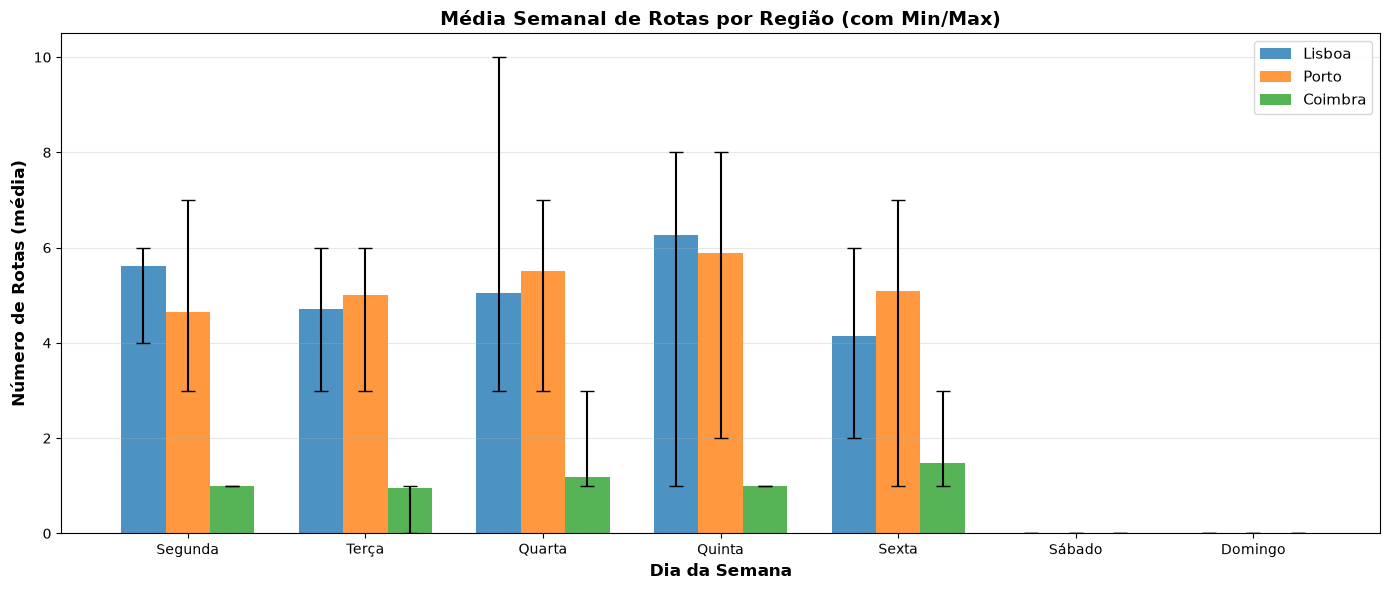

✓ Gráfico salvo


In [200]:
import matplotlib.pyplot as plt
import numpy as np

rotas_2026['NumDia'] = rotas_2026['Data'].dt.dayofweek
rotas_2026['Semana'] = rotas_2026['Data'].dt.isocalendar().week

# Agrupar por dia da semana e região
stats_dia = rotas_2026.groupby(['NumDia', 'Regiao']).agg({
    'N_Rotas': ['mean', 'min', 'max']
}).reset_index()

stats_dia.columns = ['NumDia', 'Regiao', 'media', 'minimo', 'maximo']

# Criar dataframe completo com todos os dias e regiões
dias_semana = np.arange(7)
regioes = ['Lisboa', 'Porto', 'Coimbra']

# Preencher dados faltantes
data_completa = []
for dia in dias_semana:
    for regiao in regioes:
        row = stats_dia[(stats_dia['NumDia'] == dia) & (stats_dia['Regiao'] == regiao)]
        if len(row) > 0:
            data_completa.append({
                'NumDia': dia,
                'Regiao': regiao,
                'media': row['media'].values[0],
                'minimo': row['minimo'].values[0],
                'maximo': row['maximo'].values[0]
            })
        else:
            data_completa.append({
                'NumDia': dia,
                'Regiao': regiao,
                'media': 0,
                'minimo': 0,
                'maximo': 0
            })

stats_dia_completo = pd.DataFrame(data_completa)

# Criar gráfico
fig, ax = plt.subplots(figsize=(14, 6))

dias_nome = ['Segunda', 'Terça', 'Quarta', 'Quinta', 'Sexta', 'Sábado', 'Domingo']
cores = {'Lisboa': '#1f77b4', 'Porto': '#ff7f0e', 'Coimbra': '#2ca02c'}

x = np.arange(7)
width = 0.25

for i, regiao in enumerate(regioes):
    dados = stats_dia_completo[stats_dia_completo['Regiao'] == regiao].sort_values('NumDia')
    
    erro_baixo = dados['media'].values - dados['minimo'].values
    erro_alto = dados['maximo'].values - dados['media'].values
    erro = [erro_baixo, erro_alto]
    
    ax.bar(x + i*width, dados['media'].values, width, 
           label=regiao, color=cores[regiao], alpha=0.8,
           yerr=erro, capsize=5, error_kw={'linewidth': 1.5})

ax.set_xlabel('Dia da Semana', fontsize=12, fontweight='bold')
ax.set_ylabel('Número de Rotas (média)', fontsize=12, fontweight='bold')
ax.set_title('Média Semanal de Rotas por Região (com Min/Max)', fontsize=14, fontweight='bold')
ax.set_xticks(x + width)
ax.set_xticklabels(dias_nome)
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.expanduser('~/Downloads/grafico_rotas_semanal.png'), dpi=300, bbox_inches='tight')
plt.show()

print("✓ Gráfico salvo")

In [201]:
# Filtrar Lisboa com 10 rotas
lisboa_10 = rotas_2026[(rotas_2026['Regiao'] == 'Lisboa') & (rotas_2026['N_Rotas'] == 10)]

print(f"Total dias com 10 rotas em Lisboa: {len(lisboa_10)}")
print(lisboa_10)

Total dias com 10 rotas em Lisboa: 1
          Data  Regiao  N_Rotas  Peso_Total  Peso_Medio  NumDia  Semana
311 2026-06-03  Lisboa       10     1511.45      151.15       2      23


In [202]:
# Ver df original para 2026-06-03 Lisboa
df_original_dia = df_2026_filt[
    (df_2026_filt['FENTREGA_DT'] == pd.Timestamp('2026-06-03')) & 
    (df_2026_filt['regiao'] == 'Lisboa')
]

df_original_dia

,id,PROPIETARIO,TRAYECTO,TRANSPORTISTA,TRACTORA,REMOLQUE,INGRESODT,COSTEDT,RENTADT,PALETSDT,...,CAMION_CAPACIDAD,TIPO_COMBUSTIBLE,KMREALES,ALBARAN,ficheiro_origem,FENTREGA_DT,ano,dest_cp,dest_cp2,regiao
264490,75931,PTG,SALVESEN LOGISTICA PORTUGAL / SPAR - CARREGADO...,"TRANSPORTES FLORENCIO SILVA, LDA. -",AS-19-GR,AS-19-GR,0.0,6.69,-6.69,0.11,...,4,DIESEL,16.938,SI,SAL_DAT027 (24).xls,2026-06-03,2026,2580-461,25,Lisboa
264543,75984,PTG,SALVESEN LOGISTICA PORTUGAL / SALVESEN LOGISTI...,"TRANSPORTES FLORENCIO SILVA, LDA. -",BF-27-IE,BF-27-IE,0.0,21.56,-21.56,0.09,...,5,DIESEL,86.959,NO,SAL_DAT027 (24).xls,2026-06-03,2026,2560-280,25,Lisboa
264545,75986,PTG,SALVESEN LOGISTICA PORTUGAL / SALVESEN LOGISTI...,"TRANSPORTES FLORENCIO SILVA, LDA. -",BF-27-IE,BF-27-IE,0.0,19.17,-19.17,0.08,...,5,DIESEL,0.000,NO,SAL_DAT027 (24).xls,2026-06-03,2026,2560-000,25,Lisboa
264564,76005,PTG,SALVESEN LOGISTICA PORTUGAL / SALVESEN LOGISTI...,"TRANSPORTES FLORENCIO SILVA, LDA. -",BU-35-NR,BU-35-NR,0.0,9.86,-9.86,0.13,...,5,DIESEL,67.787,NO,SAL_DAT027 (24).xls,2026-06-03,2026,2735-013,27,Lisboa
264566,76007,PTG,SALVESEN LOGISTICA PORTUGAL / SALVESEN LOGISTI...,"TRANSPORTES FLORENCIO SILVA, LDA. -",BU-35-NR,BU-35-NR,0.0,25.03,-25.03,0.33,...,5,DIESEL,66.100,NO,SAL_DAT027 (24).xls,2026-06-03,2026,2720-053,27,Lisboa
264627,76068,PTG,SALVESEN LOGISTICA PORTUGAL / SALVESEN LOGISTI...,"TRANSPORTES FLORENCIO SILVA, LDA. -",BZ-32-CL,BZ-32-CL,0.0,6.54,-6.54,0.09,...,4,DIESEL,60.662,NO,SAL_DAT027 (24).xls,2026-06-03,2026,1950-408,19,Lisboa
271303,83907,PTG,SALVESEN LOGISTICA PORTUGAL / SALVESEN LOGISTI...,"TRANSPORTES FLORENCIO SILVA, LDA. -",BP-28-VV,BP-28-VV,0.0,1.69,-1.69,0.02,...,4,DIESEL,64.167,NO,SAL_DAT027 (27).xls,2026-06-03,2026,1070-113,10,Lisboa
271304,83908,PTG,SALVESEN LOGISTICA PORTUGAL / SALVESEN LOGISTI...,"TRANSPORTES FLORENCIO SILVA, LDA. -",BP-28-VV,BP-28-VV,0.0,0.00,0.00,0.00,...,4,DIESEL,56.617,NO,SAL_DAT027 (27).xls,2026-06-03,2026,1700-031,17,Lisboa
271305,83911,PTG,SALVESEN LOGISTICA PORTUGAL / SALVESEN LOGISTI...,"TRANSPORTES FLORENCIO SILVA, LDA. -",BP-28-VV,BP-28-VV,0.0,42.31,-42.31,0.50,...,4,DIESEL,57.686,NO,SAL_DAT027 (27).xls,2026-06-03,2026,1950-005,19,Lisboa
271307,83913,PTG,SALVESEN LOGISTICA PORTUGAL / SALVESEN LOGISTI...,"TRANSPORTES FLORENCIO SILVA, LDA. -",BP-28-VV,BP-28-VV,0.0,6.77,-6.77,0.08,...,4,DIESEL,66.094,NO,SAL_DAT027 (27).xls,2026-06-03,2026,2675-672,26,Lisboa


In [203]:
output_path = os.path.expanduser('~/Downloads/Lisboa_2026-06-03.xlsx')
df_original_dia.to_excel(output_path, index=False)

print(f"✓ Ficheiro salvo: {output_path}")
print(f"Total linhas: {len(df_original_dia)}")
print(f"Total rotas únicas: {df_original_dia['TRAYECTO'].nunique()}")
print(f"Peso total: {df_original_dia['PESO_BRUTO'].sum():.2f} kg")

✓ Ficheiro salvo: C:\Users\LISARR/Downloads/Lisboa_2026-06-03.xlsx
Total linhas: 22
Total rotas únicas: 10
Peso total: 1511.45 kg


In [204]:
# Se quiser ver todas as colunas relevantes
df_original_dia[['FENTREGA_DT', 'regiao', 'CODACT', 'TRAYECTO', 'TRANSPORTISTA', 'PESO_BRUTO']].sort_values('TRAYECTO')

,FENTREGA_DT,regiao,CODACT,TRAYECTO,TRANSPORTISTA,PESO_BRUTO
271413,2026-06-03,Lisboa,13,SALVESEN LOGISTICA PORTUGAL / A.S. VOUZELA (S/...,Transportes Fernando Simões Monteiro Unip. Lda,23.97
271397,2026-06-03,Lisboa,13,SALVESEN LOGISTICA PORTUGAL / PARADI- GAFANHA ...,Transportes Fernando Simões Monteiro Unip. Lda,46.89
264543,2026-06-03,Lisboa,13,SALVESEN LOGISTICA PORTUGAL / SALVESEN LOGISTI...,"TRANSPORTES FLORENCIO SILVA, LDA. -",53.40
264545,2026-06-03,Lisboa,13,SALVESEN LOGISTICA PORTUGAL / SALVESEN LOGISTI...,"TRANSPORTES FLORENCIO SILVA, LDA. -",47.99
271342,2026-06-03,Lisboa,13,SALVESEN LOGISTICA PORTUGAL / SALVESEN LOGISTI...,"TRANSPORTES FLORENCIO SILVA, LDA. -",12.50
271355,2026-06-03,Lisboa,13,SALVESEN LOGISTICA PORTUGAL / SALVESEN LOGISTI...,"TRANSPORTES FLORENCIO SILVA, LDA. -",0.00
271357,2026-06-03,Lisboa,13,SALVESEN LOGISTICA PORTUGAL / SALVESEN LOGISTI...,"TRANSPORTES FLORENCIO SILVA, LDA. -",184.65
271359,2026-06-03,Lisboa,13,SALVESEN LOGISTICA PORTUGAL / SALVESEN LOGISTI...,"TRANSPORTES FLORENCIO SILVA, LDA. -",80.27
271360,2026-06-03,Lisboa,13,SALVESEN LOGISTICA PORTUGAL / SALVESEN LOGISTI...,"TRANSPORTES FLORENCIO SILVA, LDA. -",2.96
271361,2026-06-03,Lisboa,13,SALVESEN LOGISTICA PORTUGAL / SALVESEN LOGISTI...,"TRANSPORTES FLORENCIO SILVA, LDA. -",0.00


In [205]:
# Parece que o mapeamento por TRANSPORTISTA seria mais correto
# Refazer usando TRANSPORTISTA

df_2026_corrigido = df_2026.copy()
df_2026_corrigido['regiao'] = 'Outro'

# Coimbra = Transportes Fernando Simões Monteiro
coimbra_mask = df_2026_corrigido['TRANSPORTISTA'].str.contains('Transportes Fernando Simões', case=False, na=False)
df_2026_corrigido.loc[coimbra_mask, 'regiao'] = 'Coimbra'

# Lisboa = TRANSPORTES FLORENCIO (com CP 2 = 10-29)
florencio_mask = df_2026_corrigido['TRANSPORTISTA'].str.contains('TRANSPORTES FLORENCIO', case=False, na=False)
florencio_lis = (df_2026_corrigido['dest_cp2'].isin(['10', '11', '12', '13', '14', '15', '16', '17', '18', '19', '20', '21', '23', '24', '25', '26', '27', '28', '29']))
df_2026_corrigido.loc[florencio_mask & florencio_lis, 'regiao'] = 'Lisboa'

# Porto = TRANSPORTES FLORENCIO (com CP 2 = 40-49)
florencio_por = (df_2026_corrigido['dest_cp2'].isin(['40', '41', '42', '43', '44', '45', '46', '47', '48', '49']))
df_2026_corrigido.loc[florencio_mask & florencio_por, 'regiao'] = 'Porto'

print("Distribuição regies corrigida:")
print(df_2026_corrigido['regiao'].value_counts())

Distribuição regies corrigida:
regiao
Coimbra    7867
Porto      4116
Outro      3998
Lisboa     1808
Name: count, dtype: int64


In [206]:
# Refazer com CPOSTAL correto
df_2026_corrigido = df_2026.copy()

# Extrair cp7 e cp2 de CPOSTAL
df_2026_corrigido['dest_cp'] = df_2026_corrigido['CPOSTAL'].astype(str).str.strip()
df_2026_corrigido['dest_cp2'] = df_2026_corrigido['CPOSTAL'].astype(str).str[:2]

df_2026_corrigido['regiao'] = 'Outro'

# Coimbra = Transportes Fernando Simões Monteiro
coimbra_mask = df_2026_corrigido['TRANSPORTISTA'].str.contains('Transportes Fernando Simões', case=False, na=False)
df_2026_corrigido.loc[coimbra_mask, 'regiao'] = 'Coimbra'

# Lisboa = TRANSPORTES FLORENCIO (com CP 2 = 10-29)
florencio_mask = df_2026_corrigido['TRANSPORTISTA'].str.contains('TRANSPORTES FLORENCIO', case=False, na=False)
florencio_lis = (df_2026_corrigido['dest_cp2'].isin(['10', '11', '12', '13', '14', '15', '16', '17', '18', '19', '20', '21', '23', '24', '25', '26', '27', '28', '29']))
df_2026_corrigido.loc[florencio_mask & florencio_lis, 'regiao'] = 'Lisboa'

# Porto = TRANSPORTES FLORENCIO (com CP 2 = 40-49)
florencio_por = (df_2026_corrigido['dest_cp2'].isin(['40', '41', '42', '43', '44', '45', '46', '47', '48', '49']))
df_2026_corrigido.loc[florencio_mask & florencio_por, 'regiao'] = 'Porto'

print("Distribuição regiões corrigida:")
print(df_2026_corrigido['regiao'].value_counts())

Distribuição regiões corrigida:
regiao
Lisboa     9867
Coimbra    7867
Porto        55
Name: count, dtype: int64


In [207]:
# Filtrar só as 3 regiões (sem "Outro")
df_2026_final = df_2026_corrigido[df_2026_corrigido['regiao'].isin(['Lisboa', 'Coimbra', 'Porto'])].copy()

rotas_2026_final = df_2026_final.groupby(['FENTREGA_DT', 'regiao']).agg({'TRAYECTO': 'nunique', 'PESO_BRUTO': 'sum'}).reset_index()
rotas_2026_final.columns = ['Data', 'Regiao', 'N_Rotas', 'Peso_Total']
rotas_2026_final['Peso_Medio'] = (rotas_2026_final['Peso_Total'] / rotas_2026_final['N_Rotas']).round(2)
rotas_2026_final = rotas_2026_final.sort_values(['Data', 'Regiao'])

detalhe_2026_final = df_2026_final.groupby(['FENTREGA_DT', 'regiao', 'TRAYECTO']).agg(N_Linhas=('PESO_BRUTO', 'count'), Peso_Total=('PESO_BRUTO', 'sum'), Peso_Medio=('PESO_BRUTO', 'mean')).reset_index()
detalhe_2026_final['Peso_Total'] = detalhe_2026_final['Peso_Total'].round(2)
detalhe_2026_final['Peso_Medio'] = detalhe_2026_final['Peso_Medio'].round(2)

output_path = os.path.expanduser('~/Downloads/CAPILAR_2026_CORRIGIDO.xlsx')
with pd.ExcelWriter(output_path, engine='openpyxl') as w:
    rotas_2026_final.to_excel(w, sheet_name='Resumo_Diario', index=False)
    detalhe_2026_final.to_excel(w, sheet_name='Detalhe', index=False)

print(f"✓ Ficheiro corrigido: {output_path}")
print(f"Total: {len(df_2026_final):,} linhas")
print(f"\nPor região:")
print(rotas_2026_final.groupby('Regiao')[['N_Rotas', 'Peso_Total']].sum())

✓ Ficheiro corrigido: C:\Users\LISARR/Downloads/CAPILAR_2026_CORRIGIDO.xlsx
Total: 17,789 linhas

Por região:
         N_Rotas  Peso_Total
Regiao                      
Coimbra      543   504692.09
Lisboa      1426   800899.34
Porto         35     5527.87


In [208]:
# Resumo diário COM matrícula
rotas_2026_matricula = df_2026_final.groupby(['FENTREGA_DT', 'regiao', 'TRACTORA']).agg(
    N_Rotas=('TRAYECTO', 'nunique'), 
    Peso_Total=('PESO_BRUTO', 'sum')
).reset_index()

rotas_2026_matricula.columns = ['Data', 'Regiao', 'Matricula', 'N_Rotas', 'Peso_Total']
rotas_2026_matricula['Peso_Medio'] = (rotas_2026_matricula['Peso_Total'] / rotas_2026_matricula['N_Rotas']).round(2)
rotas_2026_matricula = rotas_2026_matricula.sort_values(['Data', 'Regiao', 'Matricula'])

# Detalhe COM matrícula
detalhe_2026_matricula = df_2026_final.groupby(['FENTREGA_DT', 'regiao', 'TRACTORA', 'CODEUT']).agg(
    Peso_Total=('PESO_BRUTO', 'sum'), 
    N_Linhas=('PESO_BRUTO', 'count')
).reset_index()

detalhe_2026_matricula.columns = ['Data', 'Regiao', 'Matricula', 'Rota', 'Peso_Total', 'N_Linhas']
detalhe_2026_matricula['Peso_Total'] = detalhe_2026_matricula['Peso_Total'].round(2)
detalhe_2026_matricula = detalhe_2026_matricula.sort_values(['Data', 'Regiao', 'Matricula', 'Rota'])

output_path = os.path.expanduser('~/Downloads/CAPILAR_2026_MATRICULA.xlsx')
with pd.ExcelWriter(output_path, engine='openpyxl') as w:
    rotas_2026_matricula.to_excel(w, sheet_name='Resumo_Diario', index=False)
    detalhe_2026_matricula.to_excel(w, sheet_name='Detalhe', index=False)

print(f"✓ Ficheiro: {output_path}")
print(f"\nResumo Diário:")
rotas_2026_matricula.head(15)

✓ Ficheiro: C:\Users\LISARR/Downloads/CAPILAR_2026_MATRICULA.xlsx

Resumo Diário:


,Data,Regiao,Matricula,N_Rotas,Peso_Total,Peso_Medio
0,2026-01-02,Coimbra,19-PJ-32,1,920.11,920.11
1,2026-01-02,Coimbra,33-VG-29,1,1043.26,1043.26
2,2026-01-02,Coimbra,AF-05-FR,1,1308.08,1308.08
3,2026-01-02,Coimbra,AT-30-MG,1,1066.92,1066.92
4,2026-01-02,Coimbra,AT-71-MG,1,1158.34,1158.34
5,2026-01-02,Lisboa,AA-86-LJ,1,15.52,15.52
6,2026-01-02,Lisboa,AS-61-IG,1,694.27,694.27
7,2026-01-02,Lisboa,AT-41-AC,1,171.86,171.86
8,2026-01-02,Lisboa,BP-28-VV,1,236.08,236.08
9,2026-01-02,Lisboa,BU-35-NR,1,414.99,414.99


In [209]:
# Primeiro refazer a classificação com PROV_DESTINO
df_2026_corrigido_v2 = df_2026.copy()

df_2026_corrigido_v2['regiao'] = 'Outro'

# Coimbra = Transportes Fernando Simões Monteiro
coimbra_mask = df_2026_corrigido_v2['TRANSPORTISTA'].str.contains('Transportes Fernando Simões', case=False, na=False)
df_2026_corrigido_v2.loc[coimbra_mask, 'regiao'] = 'Coimbra'

# Lisboa = TRANSPORTES FLORENCIO + PROV_DESTINO = Lisboa
florencio_mask = df_2026_corrigido_v2['TRANSPORTISTA'].str.contains('TRANSPORTES FLORENCIO', case=False, na=False)
df_2026_corrigido_v2.loc[florencio_mask & (df_2026_corrigido_v2['PROV_DESTINO'] == 'Lisboa'), 'regiao'] = 'Lisboa'

# Porto = TRANSPORTES FLORENCIO + PROV_DESTINO = Porto
df_2026_corrigido_v2.loc[florencio_mask & (df_2026_corrigido_v2['PROV_DESTINO'] == 'Porto'), 'regiao'] = 'Porto'

print("Distribuição com PROV_DESTINO:")
print(df_2026_corrigido_v2['regiao'].value_counts())

# Agora verificar matrículas
matriculas = ['AS-19-GR', 'AS-61-IG', 'AT-41-AC', 'AV-19-VM', 'BF-27-IE', 'BP-28-VV', 'BQ-14-UF', 'BQ-16-UF', 'BR-15-MN', 'BR-51-ZV', 'BS-59-BC', 'BU-35-NR', 'BZ-32-CL', 'CF-67-PG']

df_check = df_2026_corrigido_v2[
    (df_2026_corrigido_v2['TRACTORA'].isin(matriculas)) & 
    (df_2026_corrigido_v2['regiao'].isin(['Porto', 'Coimbra']))
]

print(f"\n\nTotal ocorrências em Porto/Coimbra: {len(df_check)}")
print(f"\nPor região:")
print(df_check['regiao'].value_counts())

print(f"\nMatrículas encontradas:")
print(df_check['TRACTORA'].value_counts())

Distribuição com PROV_DESTINO:
regiao
Coimbra    7867
Outro      7755
Porto      1313
Lisboa      854
Name: count, dtype: int64


Total ocorrências em Porto/Coimbra: 1033

Por região:
regiao
Porto    1033
Name: count, dtype: int64

Matrículas encontradas:
TRACTORA
BQ-16-UF    724
BR-15-MN    146
BS-59-BC     60
BR-51-ZV     58
BQ-14-UF     27
AV-19-VM     12
CF-67-PG      6
Name: count, dtype: int64


In [210]:
matriculas = ['AS-19-GR', 'AS-61-IG', 'AT-41-AC', 'AV-19-VM', 'BF-27-IE', 'BP-28-VV', 'BQ-14-UF', 'BQ-16-UF', 'BR-15-MN', 'BR-51-ZV', 'BS-59-BC', 'BU-35-NR', 'BZ-32-CL', 'CF-67-PG']

# Verificar se estas matrículas existem em Porto ou Coimbra
df_check = df_2026_corrigido_v2[
    (df_2026_corrigido_v2['TRACTORA'].isin(matriculas)) & 
    (df_2026_corrigido_v2['regiao'].isin(['Porto', 'Coimbra']))
]

print(f"Total ocorrências em Porto/Coimbra: {len(df_check)}")
print(f"\nPor região:")
print(df_check['regiao'].value_counts())

print(f"\nMatrículas encontradas:")
print(df_check['TRACTORA'].value_counts())

Total ocorrências em Porto/Coimbra: 1033

Por região:
regiao
Porto    1033
Name: count, dtype: int64

Matrículas encontradas:
TRACTORA
BQ-16-UF    724
BR-15-MN    146
BS-59-BC     60
BR-51-ZV     58
BQ-14-UF     27
AV-19-VM     12
CF-67-PG      6
Name: count, dtype: int64


In [211]:
import os

# Classificação final usando PROV_DESTINO
df_2026_final_v2 = df_2026.copy()
df_2026_final_v2['regiao'] = 'Outro'

# Coimbra = Transportes Fernando Simões
coimbra_mask = df_2026_final_v2['TRANSPORTISTA'].str.contains('Transportes Fernando Simões', case=False, na=False)
df_2026_final_v2.loc[coimbra_mask, 'regiao'] = 'Coimbra'

# Lisboa/Porto = por PROV_DESTINO
df_2026_final_v2.loc[df_2026_final_v2['PROV_DESTINO'] == 'Lisboa', 'regiao'] = 'Lisboa'
df_2026_final_v2.loc[df_2026_final_v2['PROV_DESTINO'] == 'Porto', 'regiao'] = 'Porto'

df_2026_final = df_2026_final_v2[df_2026_final_v2['regiao'].isin(['Lisboa', 'Coimbra', 'Porto'])].copy()

# Resumo diário COM matrícula
rotas_2026_corrigido = df_2026_final.groupby(['FENTREGA_DT', 'regiao', 'TRACTORA']).agg(
    N_Rotas=('TRAYECTO', 'nunique'), 
    Peso_Total=('PESO_BRUTO', 'sum')
).reset_index()

rotas_2026_corrigido.columns = ['Data', 'Regiao', 'Matricula', 'N_Rotas', 'Peso_Total']
rotas_2026_corrigido['Peso_Medio'] = (rotas_2026_corrigido['Peso_Total'] / rotas_2026_corrigido['N_Rotas']).round(2)
rotas_2026_corrigido = rotas_2026_corrigido.sort_values(['Data', 'Regiao', 'Matricula'])

# Detalhe COM matrícula
detalhe_2026_corrigido = df_2026_final.groupby(['FENTREGA_DT', 'regiao', 'TRACTORA', 'CODEUT']).agg(
    Peso_Total=('PESO_BRUTO', 'sum'), 
    N_Linhas=('PESO_BRUTO', 'count')
).reset_index()

detalhe_2026_corrigido.columns = ['Data', 'Regiao', 'Matricula', 'Rota', 'Peso_Total', 'N_Linhas']
detalhe_2026_corrigido['Peso_Total'] = detalhe_2026_corrigido['Peso_Total'].round(2)
detalhe_2026_corrigido = detalhe_2026_corrigido.sort_values(['Data', 'Regiao', 'Matricula', 'Rota'])

output_path = os.path.expanduser('~/Downloads/CAPILAR_2026_FINAL.xlsx')
with pd.ExcelWriter(output_path, engine='openpyxl') as w:
    rotas_2026_corrigido.to_excel(w, sheet_name='Resumo_Diario', index=False)
    detalhe_2026_corrigido.to_excel(w, sheet_name='Detalhe', index=False)

print(f"✓ Ficheiro: {output_path}")
print(f"\nDistribuição final:")
print(df_2026_final['regiao'].value_counts())
print(f"\n\nResumo por região:")
print(rotas_2026_corrigido.groupby('Regiao')[['N_Rotas', 'Peso_Total']].sum())

✓ Ficheiro: C:\Users\LISARR/Downloads/CAPILAR_2026_FINAL.xlsx

Distribuição final:
regiao
Coimbra    7834
Porto      1346
Lisboa      854
Name: count, dtype: int64


Resumo por região:
         N_Rotas  Peso_Total
Regiao                      
Coimbra      543   502339.51
Lisboa       362    46893.98
Porto        360   113746.47
